# Установка зависимостей

In [ ]:
!pip install pandas numpy matplotlib scikit-learn tensorflow

# Импорт

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Загрузка данных

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Размер обучающей выборки: (50000, 32, 32, 3)
Размер тестовой выборки: (10000, 32, 32, 3)


# Предобработка данных

In [3]:
# Нормализация
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# Преобразование меток в one-hot векторы
num_classes = len(np.unique(y_train))
Y_train = to_categorical(y_train, num_classes)
Y_test  = to_categorical(y_test, num_classes)

# Генерация модели


In [4]:
def create_cnn(kernel_size=3, use_dropout=True):
    """
    Создает сверточную нейронную сеть для CIFAR-10.

    Параметры:
        kernel_size : int – размер ядра свертки (по умолчанию 3)
        use_dropout : bool – использовать ли Dropout слои
    """
    # Входной слой: изображения 32x32 с 3 каналами (RGB)
    inp = Input(shape=(32, 32, 3))

    # Блок 1: две свертки 32 фильтра, затем подвыборка и опционально Dropout
    conv_1 = Conv2D(32, kernel_size, padding='same', activation='relu')(inp)
    conv_2 = Conv2D(32, kernel_size, padding='same', activation='relu')(conv_1)
    pool_1 = MaxPooling2D(pool_size=(2, 2))(conv_2)
    if use_dropout:
        pool_1 = Dropout(0.25)(pool_1)

    # Блок 2: две свертки 64 фильтра, затем подвыборка и опционально Dropout
    conv_3 = Conv2D(64, kernel_size, padding='same', activation='relu')(pool_1)
    conv_4 = Conv2D(64, kernel_size, padding='same', activation='relu')(conv_3)
    pool_2 = MaxPooling2D(pool_size=(2, 2))(conv_4)
    if use_dropout:
        pool_2 = Dropout(0.25)(pool_2)

    # Переход к полносвязным слоям
    flat = Flatten()(pool_2)
    hidden = Dense(512, activation='relu')(flat)
    if use_dropout:
        hidden = Dropout(0.5)(hidden)
    out = Dense(num_classes, activation='softmax')(hidden)

    model = Model(inputs=inp, outputs=out)
    return model

# Обучение и оценка модели

In [5]:
def train_and_evaluate(model, epochs=20, batch_size=32, verbose=1):
    model.compile(
        loss='categorical_crossentropy',
        optimizer=Adam(),
        metrics=['accuracy']
    )
    history = model.fit(
        X_train, Y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_split=0.1,
        verbose=verbose
    )
    score = model.evaluate(X_test, Y_test, verbose=0)
    print(f"Test loss: {score[0]:.4f}, Test accuracy: {score[1]:.4f}")
    return history, score[1]

# Исследование

In [ ]:
kernel_sizes = [3, 5]
results = {}
histories = {}
for k in kernel_sizes:
  for droput in [True, False]:
    name = f"Dropout={droput}, k={k}"
    print(name)
    model = create_cnn(kernel_size=k, use_dropout=droput)
    hist, acc = train_and_evaluate(model, epochs=20, verbose=1)
    results[(droput, k)] = (hist, acc)
    histories[(droput, k)] = hist

Dropout=True, k=3
Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 282s 198ms/step - accuracy: 0.3278 - loss: 1.8018 - val_accuracy: 0.5870 - val_loss: 1.1653
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 278s 198ms/step - accuracy: 0.5842 - loss: 1.1665 - val_accuracy: 0.6844 - val_loss: 0.9318
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 283s 201ms/step - accuracy: 0.6506 - loss: 0.9812 - val_accuracy: 0.7236 - val_loss: 0.7948
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 283s 201ms/step - accuracy: 0.6914 - loss: 0.8697 - val_accuracy: 0.7382 - val_loss: 0.7508
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 283s 201ms/step - accuracy: 0.7189 - loss: 0.7926 - val_accuracy: 0.7492 - val_loss: 0.7536
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 316s 196ms/step - accuracy: 0.7349 - loss: 0.7377 - val_accuracy: 0.7556 - val_loss: 0.6981
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 321s 196ms/step - accuracy: 0.7587 - loss: 0.6910 - val_accuracy: 0.7640 - val_loss: 0.6920
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27

In [54]:
def plot_dropout_group(histories, kernel_sizes, dropout):
  plt.figure(figsize=(14, 5))
  plt.suptitle(f"Сравнение размеров ядра ({'с' if dropout else 'без'} Dropout)")

  colors = plt.cm.tab10(np.linspace(0, 1, len(kernel_sizes)))

  plt.subplot(1, 2, 1)
  for idx, k in enumerate(kernel_sizes):
      hist = histories[(dropout, k)]
      color = colors[idx]
      plt.plot(hist.history['accuracy'], label=f'k={k} (train)', color=color)
      plt.plot(hist.history['val_accuracy'], '--', label=f'k={k} (val)', color=color)
  plt.title(f'Точность')
  plt.xlabel('Эпоха')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.grid(True)

  plt.subplot(1, 2, 2)
  for idx, k in enumerate(kernel_sizes):
      hist = histories[(dropout, k)]
      color = colors[idx]
      plt.plot(hist.history['loss'], label=f'k={k} (train)', color=color)
      plt.plot(hist.history['val_loss'], '--', label=f'k={k} (val)', color=color)
  plt.title('Потери')
  plt.xlabel('Эпоха')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)

  plt.tight_layout()
  plt.show()

def plot_kernel_size(histories, kernel_size):
  plt.figure(figsize=(14, 5))
  plt.suptitle(f"Сравнение с Dropout и без (k={kernel_size})")

  colors = plt.cm.tab10(np.linspace(0, 1, len(kernel_sizes)))

  plt.subplot(1, 2, 1)
  hist_drop = histories[(True, kernel_size)]
  plt.plot(hist_drop.history['accuracy'], label='с Dropout (train)', color=colors[0])
  plt.plot(hist_drop.history['val_accuracy'], '--', label='с Dropout (val)', color=colors[0])
  hist_nodrop = histories[(False, kernel_size)]
  plt.plot(hist_nodrop.history['accuracy'], label='без Dropout (train)', color=colors[1])
  plt.plot(hist_nodrop.history['val_accuracy'], '--', label='без Dropout (val)', color=colors[1])
  plt.title(f'Точность на валидации (k={kernel_size})')
  plt.xlabel('Эпоха')
  plt.ylabel('Точность')
  plt.legend()
  plt.grid(True)

  plt.subplot(1, 2, 2)
  plt.plot(hist_drop.history['loss'], label='с Dropout (train)', color=colors[0])
  plt.plot(hist_drop.history['val_loss'], '--', label='с Dropout (val)', color=colors[0])
  plt.plot(hist_nodrop.history['loss'], label='без Dropout (train)', color=colors[1])
  plt.plot(hist_nodrop.history['val_loss'], '--', label='без Dropout (val)', color=colors[1])
  plt.title(f'Потери на валидации (k={kernel_size})')
  plt.xlabel('Эпоха')
  plt.ylabel('Loss')
  plt.legend()
  plt.grid(True)

  plt.tight_layout()
  plt.show()

In [13]:
# Словари histories и results, сформированные по предоставленному логу
kernel_sizes = [3, 5]
histories = {
    (True, 3): type('History', (), {'history': {
        'accuracy': [0.3278, 0.5842, 0.6506, 0.6914, 0.7189, 0.7349, 0.7587, 0.7675, 0.7765, 0.7864, 0.7999, 0.8035, 0.8124, 0.8151, 0.8226, 0.8309, 0.8351, 0.8374, 0.8447, 0.8458],
        'loss': [1.8018, 1.1665, 0.9812, 0.8697, 0.7926, 0.7377, 0.6910, 0.6520, 0.6248, 0.5994, 0.5612, 0.5551, 0.5248, 0.5149, 0.5001, 0.4788, 0.4675, 0.4545, 0.4431, 0.4398],
        'val_accuracy': [0.5870, 0.6844, 0.7236, 0.7382, 0.7492, 0.7556, 0.7640, 0.7736, 0.7864, 0.7780, 0.7700, 0.7720, 0.7782, 0.7862, 0.7794, 0.7924, 0.7856, 0.7896, 0.7834, 0.7926],
        'val_loss': [1.1653, 0.9318, 0.7948, 0.7508, 0.7536, 0.6981, 0.6920, 0.6777, 0.6400, 0.6535, 0.6792, 0.6835, 0.6518, 0.6692, 0.6792, 0.6391, 0.6813, 0.6626, 0.6715, 0.6756]
    }}),

    (False, 3): type('History', (), {'history': {
        'accuracy': [0.4072, 0.6858, 0.7697, 0.8400, 0.8929, 0.9372, 0.9605, 0.9643, 0.9712, 0.9727, 0.9774, 0.9773, 0.9802, 0.9800, 0.9805, 0.9820, 0.9825, 0.9829, 0.9804, 0.9871],
        'loss': [1.6178, 0.8846, 0.6411, 0.4522, 0.3015, 0.1807, 0.1167, 0.1012, 0.0830, 0.0801, 0.0682, 0.0708, 0.0601, 0.0600, 0.0646, 0.0567, 0.0564, 0.0563, 0.0620, 0.0409],
        'val_accuracy': [0.6506, 0.7360, 0.7528, 0.7672, 0.7506, 0.7516, 0.7294, 0.7536, 0.7430, 0.7460, 0.7324, 0.7530, 0.7428, 0.7506, 0.7512, 0.7414, 0.7402, 0.7412, 0.7344, 0.7384],
        'val_loss': [0.9844, 0.7626, 0.7332, 0.7346, 0.8471, 1.0304, 1.2467, 1.2722, 1.5118, 1.4400, 1.6579, 1.6808, 1.7902, 1.7839, 1.7997, 2.0789, 1.9879, 2.1489, 2.2117, 2.0719]
    }}),

    (True, 5): type('History', (), {'history': {
        'accuracy': [0.2900, 0.5139, 0.5792, 0.6217, 0.6481, 0.6729, 0.6889, 0.7045, 0.7106, 0.7260, 0.7381, 0.7457, 0.7485, 0.7534, 0.7616, 0.7666, 0.7743, 0.7748, 0.7823, 0.7920],
        'loss': [1.8946, 1.3516, 1.1897, 1.0667, 0.9945, 0.9435, 0.8859, 0.8391, 0.8192, 0.7806, 0.7502, 0.7246, 0.7117, 0.7053, 0.6795, 0.6576, 0.6481, 0.6334, 0.6145, 0.5927],
        'val_accuracy': [0.5130, 0.5896, 0.6522, 0.6700, 0.6858, 0.6942, 0.7132, 0.7164, 0.7188, 0.7270, 0.7246, 0.7316, 0.7428, 0.7370, 0.7338, 0.7346, 0.7458, 0.7330, 0.7390, 0.7474],
        'val_loss': [1.3250, 1.1418, 1.0137, 0.9611, 0.9137, 0.8990, 0.8476, 0.8439, 0.8398, 0.8235, 0.8225, 0.8203, 0.7859, 0.7862, 0.7883, 0.7947, 0.7843, 0.7904, 0.8062, 0.7682]
    }}),

    (False, 5): type('History', (), {'history': {
        'accuracy': [0.3581, 0.6069, 0.7039, 0.7700, 0.8331, 0.8856, 0.9233, 0.9453, 0.9527, 0.9527, 0.9606, 0.9646, 0.9692, 0.9647, 0.9712, 0.9713, 0.9757, 0.9728, 0.9707, 0.9784],
        'loss': [1.7492, 1.1039, 0.8411, 0.6523, 0.4785, 0.3248, 0.2194, 0.1601, 0.1422, 0.1391, 0.1204, 0.1088, 0.0952, 0.1097, 0.0888, 0.0930, 0.0790, 0.0913, 0.1007, 0.0708],
        'val_accuracy': [0.5774, 0.6518, 0.6982, 0.7064, 0.7196, 0.7080, 0.7132, 0.7016, 0.6882, 0.6928, 0.7054, 0.6914, 0.6914, 0.6980, 0.7108, 0.6968, 0.6996, 0.6824, 0.6944, 0.6944],
        'val_loss': [1.1822, 1.0068, 0.8743, 0.8969, 0.8909, 1.0996, 1.2407, 1.4623, 1.6931, 1.8584, 1.7697, 2.0064, 2.0648, 2.0084, 2.0795, 2.2439, 2.3103, 2.7876, 2.6533, 2.3366]
    }})
}

results = {
    (True, 3): (histories[(True, 3)], 0.7786),
    (False, 3): (histories[(False, 3)], 0.7262),
    (True, 5): (histories[(True, 5)], 0.7392),
    (False, 5): (histories[(False, 5)], 0.6838)
}

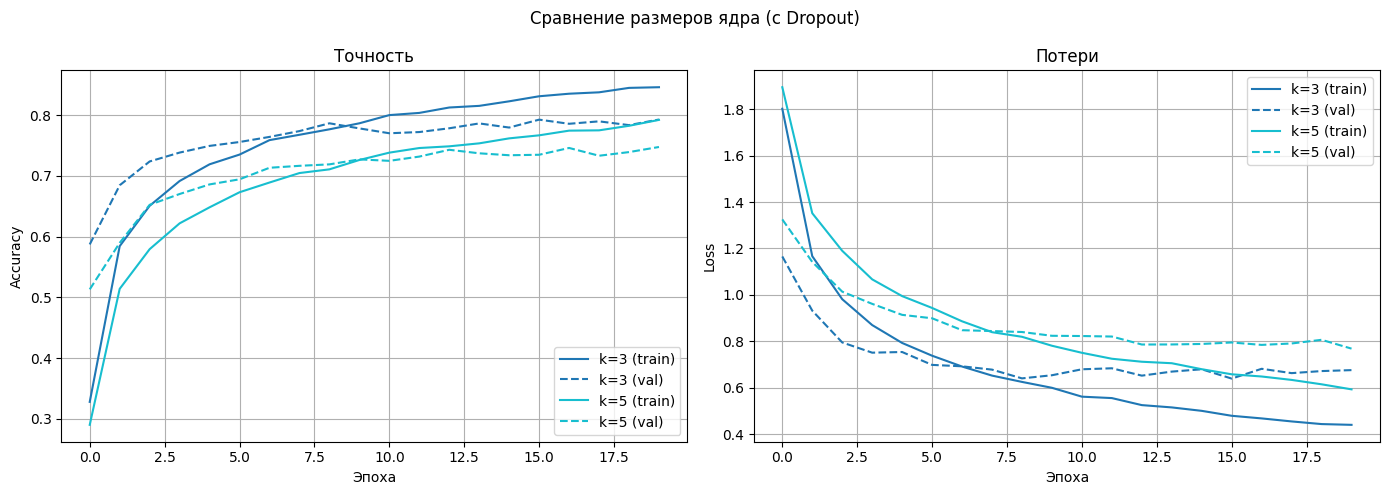

In [55]:
plot_dropout_group(histories, kernel_sizes, True)

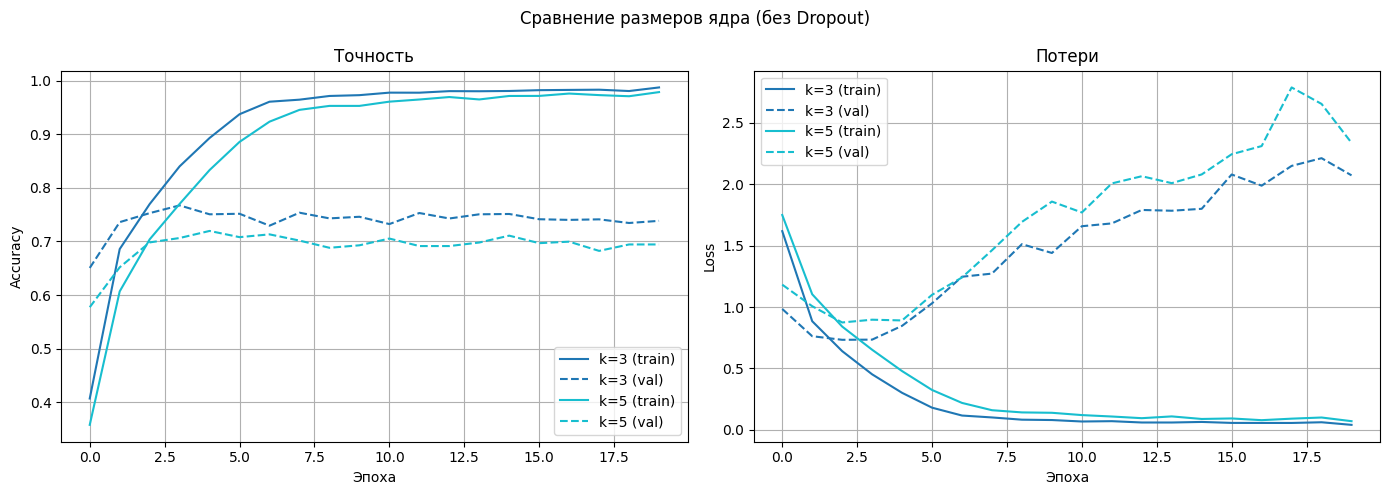

In [56]:
plot_dropout_group(histories, kernel_sizes, False)

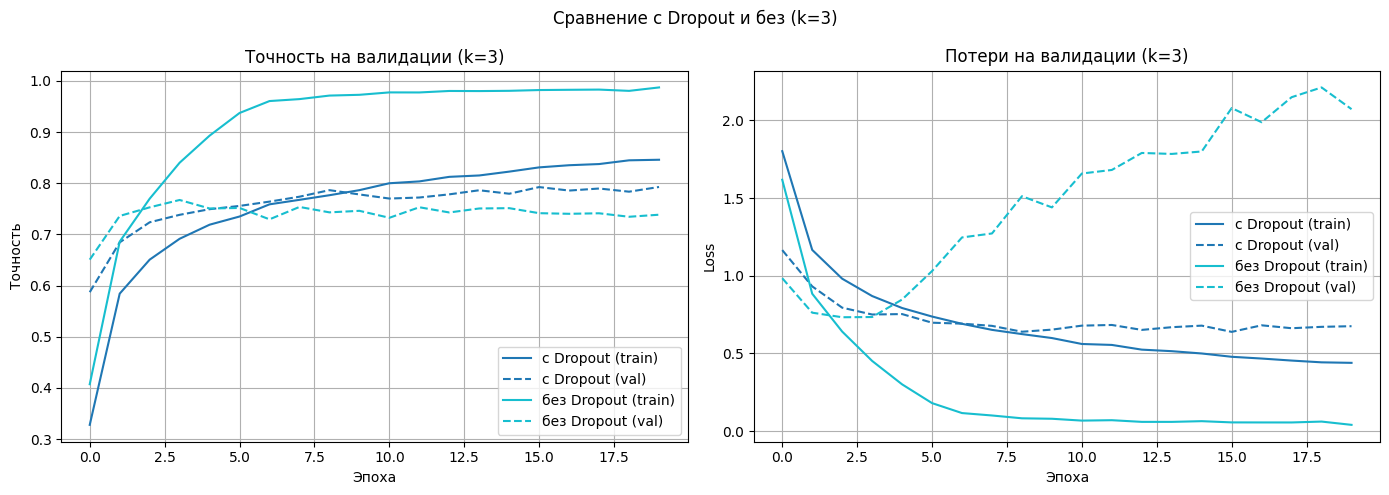

In [57]:
plot_kernel_size(histories, 3)